# Agents: Adding tools to an agent
---

`Tools` are an abstraction in LangChain that associates a python function with a schema that defines the function's name, description and expected arguments. `Tools` can then be passed to chat models that support `tool calling` allowing the model to request the execution of that function with the required parameters as provided in the schema.

#### What is Tool Calling?

Many AI applications interact directly with humans but what if there was a way for Large Language Models (`LLMs`) to interact directly with systems, such as your databases or external APIs? These systems often have a specific input schema, for example APIs frequently require a payload structure. For this, tool calling enables this functionality:

1. **Tool Creation**: Use the `@tool` decorator to create a tool. A tool is an association between a function and its respective schema.

1. **Tool Binding**: The tool needs to be connected to a model that supports tool calling. This gives model the awareness of the tool and the associated input schema that is required.

1. **Tool Calling**: When appropriate, the model can decide to call a tool and ensure its response conforms to the tool's output schema.

2. **Tool Execution**: The tool can be executed using the arguments provided by the model.

In this short lab, we will see how we can create tools, use tools and use that within our simple agent. We will use the same example from our previous notebook to create a simple agent with certain tools. 

### Set up and imports

In [1]:
# first, lets import the necessary libraries required to build the agent in this notebook
from typing import TypedDict, Annotated, List, Optional
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image, display

### Step 1: Define the Agent State

We will first define the agent state that will remain throughout the operation. This is the state of the graph and the state schema serves as the input for all nodes and edges in the graph.

In [2]:
class PlannerState(TypedDict):
    messages: List
    itinerary: Optional[str]
    city: str
    user_message: str
    weather_info: Optional[str]
    attractions_info: Optional[str]

### Step 2: Set up language models and prompts

Next, we will set up LLM and a prompt template that will be used by our agent in planning the trip.

In [3]:
# represents the global variables used across this notebook
BEDROCK_RUNTIME: str = 'bedrock-runtime'
# Model ID used by the agent
AMAZON_NOVA_LITE_MODEL_ID: str = "us.amazon.nova-lite-v1:0"
PROVIDER_ID : str = 'amazon'
# Inference parameters
TEMPERATURE: float = 0.1
MAX_TOKENS: int = 512

In [4]:
import boto3
import logging
# We are importing this to use any model supported on Amazon Bedrock. In this example
# we will be using the Amazon Nova lite model.
from langchain_aws import ChatBedrockConverse
# This helps checkpoint the memory state of the agent for short term/long term memory
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables.config import RunnableConfig
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [5]:
# set a logger
logging.basicConfig(format='[%(asctime)s] p%(process)s {%(filename)s:%(lineno)d} %(levelname)s - %(message)s', level=logging.INFO)
logger = logging.getLogger(__name__)

In [6]:
session = boto3.session.Session()
region = session.region_name
logger.info(f"Running this example in region: {region}")

# Initialize the bedrock client placeholder
bedrock_client = boto3.client("bedrock-runtime")

[2025-03-27 10:45:26,555] p7519 {2342708946.py:3} INFO - Running this example in region: us-west-2
[2025-03-27 10:45:26,592] p7519 {credentials.py:1352} INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [20]:
# Create the llm used by the agent
llm = ChatBedrockConverse(
    model=AMAZON_NOVA_LITE_MODEL_ID,
    provider=PROVIDER_ID, 
    temperature=TEMPERATURE, 
    max_tokens=MAX_TOKENS,
    client=bedrock_client,
)


# Initialize the itinerary prompt that will be used across the agent workflow. This gives agent instructions and guidance while executing tasks based
# on the user request
ITINERARY_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful travel assistant. Create a day trip itinerary based on the user's interests.
    
    For city {city}:
    
    1. Consider the user's interests and preferences.
    2. Always account for travel time and meal times - if it's not possible to do everything, then say so.
    3. If the user hasn't stated a time of year or season, assume summer season and state this assumption in your response.
    4. If the user hasn't stated a travel budget, assume a reasonable dollar amount and state this assumption in your response.
    5. Use your tools to get weather information and find tourist attractions, especially those related to boating and swimming.
    6. Provide a brief, bulleted itinerary in chronological order with specific hours of day.
    7. Include recommendations for breakfast, lunch, and dinner with specific restaurant names.
    """),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}"),
])

### Create tools and binding them to an LLM
---

In this section of the notebook, we have now created the `llm` (using `Amazon Nova Lite`). `Amazon Nova Lite` supports function calling. In this case, we can create a function or tools with the `@tool` decorator and associate these tools to the `llm`. The `llm` will then use the tools during invocation and determine which tool to use when a user asks a question.


```python
# Tool creation
tools = [my_tool]
# Tool binding
model_with_tools = model.bind_tools(tools)
# Tool calling 
response = model_with_tools.invoke(user_input)
```

Now, we will create two tools that our `LLM` will have access to while executing the user request:

1. **Search tourist attractions**: We will create a function that does a web search using the `TAVILY` API. This API will be used with the city as requested by the user to look for tourist attractions.

1. **Get weather forecast**: This tool will be used to get insights into the current weather in the city as requested by the user for which they are wanting to create an itinerary.

In [21]:
import os
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")  
WEATHER_API_KEY = os.environ.get("WEATHER_API_KEY")

In [ ]:
import requests
from langchain_core.tools import tool

def input_interest(state: PlannerState) -> PlannerState:
    """
    This function takes a PlannerState object as input and processes the user's message.
    It initializes messages if needed and ensures the state has basic required fields.
    """
    # Log the processing
    logger.info(f"Processing input for city: {state.get('city', 'unknown')}")
    
    # Initialize messages if they don't exist
    if not state.get('messages'): 
        state['messages'] = []
    
    # No complex processing needed, just return the updated state
    return {
        **state
    }

# The node that creates an itinerary using the ReAct agent
def create_itinerary(state: PlannerState) -> PlannerState:
    """
    This function takes a PlannerState object as input and creates an itinerary
    using the ReAct agent. It formats the agent input correctly and handles any errors.
    """
    try:
        # Format the input exactly as required by the ReAct agent prompt
        agent_input = {
            "input": state['user_message'],
            "chat_history": state.get('messages', []),
            "city": state['city']
        }
        
        # Log that we're invoking the agent
        logger.info("Invoking ReAct agent for itinerary creation")
        
        # Invoke the ReAct agent - make sure you use the right variable name!
        # This should be the name of your ReAct agent created with create_react_agent
        result = react.invoke(agent_input)
        
        # Extract the output from the result
        # The ReAct agent returns a dict with an "output" key
        itinerary = result.get("output", "No itinerary could be generated.")
        
        # Log success
        logger.info("Successfully generated itinerary")
        print("\nItinerary plan:")
        print(itinerary)
        
        # Return the updated state with the new messages and itinerary
        return {
            **state,
            'messages': [
                *state.get('messages', []),
                HumanMessage(content=state['user_message']),
                AIMessage(content=itinerary)
            ],
            'itinerary': itinerary
        }
    except Exception as e:
        # Log the error
        logger.error(f"Error creating itinerary: {e}")
        error_message = f"I apologize, but I encountered an error while creating your itinerary: {str(e)}"
        
        # Print the full traceback for debugging
        import traceback
        traceback.print_exc()
        
        # Return a valid state even on error
        return {
            **state,
            'messages': [
                *state.get('messages', []),
                HumanMessage(content=state['user_message']),
                AIMessage(content=error_message)
            ],
            'itinerary': error_message
        }

In [23]:
tools = [search_tourist_attractions, get_weather_forecast]

In [24]:
from langgraph.prebuilt import create_react_agent

# Create the llm used by the agent with tools
get_realtime_info_react_llm = create_react_agent(llm, tools=tools, prompt=ITINERARY_PROMPT)

### Define the nodes and Edges
---

Next, we will be adding nodes, edges and persistent memory to the `StateGraph` before we compile it.

1. user travel plans
1. invoke with Bedrock
1. generate the travel plan for the day
1. ability to add or modify the plan

In [33]:
# The first node that solely inputs a user message
# The first node that takes in user input
def input_interest(state: PlannerState) -> PlannerState:
    """
    This function processes the user's message.
    """
    logger.info(f"Processing input for city: {state.get('city', 'unknown')}")
    
    # Initialize messages if needed
    if not state.get('messages'): 
        state['messages'] = []
    
    # Return updated state
    return {
        **state
    }


# Create itinerary function - THIS IS THE FIXED VERSION
def create_itinerary(state: PlannerState) -> PlannerState:
    """
    This function creates an itinerary using the ReAct agent.
    """
    try:
        # Invoke the ReAct agent
        logger.info("Invoking ReAct agent for itinerary creation")
        result = get_realtime_info_react_llm.invoke(ITINERARY_PROMPT.format_messages(city=state['city'], user_message=state['user_message'], chat_history=state['messages']))
        
        # Extract the output from the result
        itinerary = result.get("output", "No itinerary could be generated.")
        
        logger.info("Successfully generated itinerary")
        print("\nItinerary plan:")
        print(itinerary)
        
        # Return updated state
        return {
            **state,
            'messages': [
                *state.get('messages', []),
                HumanMessage(content=state['user_message']),
                AIMessage(content=itinerary)
            ],
            'itinerary': itinerary
        }
    except Exception as e:
        logger.error(f"Error creating itinerary: {e}")
        error_message = f"I apologize, but I encountered an error while creating your itinerary: {str(e)}"
        
        # Print the exception for debugging
        import traceback
        traceback.print_exc()
        
        # Return updated state with error
        return {
            **state,
            'messages': [
                *state.get('messages', []),
                HumanMessage(content=state['user_message']),
                AIMessage(content=error_message)
            ],
            'itinerary': error_message
        }

### Create and Compile the Graph
---

In this portion of the notebook, we will create our `LangGraph` workflow and then compile it.

1. First, we will initialize the `StateGraph` with the `State` class that we defined above
1. Then, we add our nodes and edges.
1. We use the `START` Node, a special node that sends user input to the graph, to indicate where to start our graph.
1. The `END` Node is a special node that represents a terminal node.

In [34]:
# initialize the StateGraph
workflow = StateGraph(PlannerState)
# Next, we will add our nodes to this workflow
workflow.add_node("input_user_interests", input_interest)
workflow.add_node("create_itinerary", create_itinerary)
workflow.set_entry_point("input_user_interests")
# Next, we will add a direct edge between input interests and create itinerary
workflow.add_edge("input_user_interests", "create_itinerary")
workflow.add_edge("create_itinerary", END)

In [35]:
# Next, we create a checkpointer which will let us have the graph persist its state
# this is a complete memory for the entire graph
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

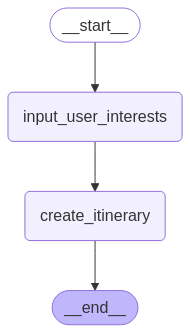

In [36]:
# Now that we have compiled the graph, we can view it in a mermaid diagram. You can use Mermaid
# to generate diagrams from markdown-like text.

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

From the graph above, we can see that from the start point, the user can input the message or their interests for the itinerary. Next, according to the next node, the llm will be invoked with the custom prompt template to create that itinerary. This is a hello world example of a simple agent on `LangGraph`.

### Define the function that runs the graph
---

When we compile the graph, we turn it into a `LangChain` Runnable, which automatically enables calling `.invoke()`, `.stream()` and `.batch()` with your inputs. In the following example, we run `stream()` to invoke the graph with inputs

In [37]:
from typing import Dict, Any
def run_travel_planner(user_request: str, city_request: str, config_dict: Optional[Dict[str, Any]] = None):
    """
    Run the travel planner with user request and city.
    
    Args:
        user_request: The user's travel request
        city_request: The city to create an itinerary for
        config_dict: Optional configuration
    """
    print(f"Current User Request: {user_request}")
    print(f"City of interest: {city_request}")
    
    # Initialize input
    init_input = {
        "user_message": user_request,
        "city": city_request,
        "messages": []
    }
    
    # Use default config if none provided
    if config_dict is None:
        config_dict = {"configurable": {"thread_id": "default"}}
    
    try:
        # Execute the workflow with streaming
        for output in app.stream(init_input, config=config_dict, stream_mode="values"):
            pass  # The nodes themselves handle printing
        
        # Get the final output
        final_output = app.invoke(init_input, config=config_dict)
        return final_output
    except Exception as e:
        logger.error(f"Error in travel planner workflow: {e}")
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()
        return {"error": str(e)}

In [38]:
# lets run the example

# thread_id within the configurable object serves as a unique identifier for the conversation session. This ID is used by the graph to: Track which conversation a message belongs to and
# maintain separate conversation histories for different users or sessions
config = {"configurable": {"thread_id": "2"}}

config = {"configurable": {"thread_id": "example-thread"}}
    
# I want to create an itinerary for a day trip in NYC with boating and swimming options. Make it extremely comprehensive and should include meals as well. Need the weather as well
user_request = input("Enter your travel request: ")
city = input("Enter the city: ")

# Run the travel planner
result = run_travel_planner(user_request, city, config)

[2025-03-27 10:54:12,211] p7519 {1277594837.py:7} INFO - Processing input for city: 
[2025-03-27 10:54:12,212] p7519 {1277594837.py:26} INFO - Invoking ReAct agent for itinerary creation
[2025-03-27 10:54:12,213] p7519 {1277594837.py:47} ERROR - Error creating itinerary: 'input'
Traceback (most recent call last):
  File "/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_7519/1277594837.py", line 27, in create_itinerary
    result = get_realtime_info_react_llm.invoke(ITINERARY_PROMPT.format_messages(city=state['city'], user_message=state['user_message'], chat_history=state['messages']))
                                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langchain_core/prompts/chat.py", line 1227, in format_messages
    message = message_template.format_message

Current User Request: 
City of interest: 


Traceback (most recent call last):
  File "/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_7519/1277594837.py", line 27, in create_itinerary
    result = get_realtime_info_react_llm.invoke(ITINERARY_PROMPT.format_messages(city=state['city'], user_message=state['user_message'], chat_history=state['messages']))
                                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langchain_core/prompts/chat.py", line 1227, in format_messages
    message = message_template.format_messages(**kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langchain_core/prompts/chat.py", line 614, in format_messages
    return [self.format(**kw

In [39]:
config = {"configurable": {"thread_id": "example-thread"}}
result = run_travel_planner(
    "I want to create an itinerary for a day trip in NYC with boating and swimming options.",
    "NYC",
    config
)

[2025-03-27 10:54:13,688] p7519 {1277594837.py:7} INFO - Processing input for city: NYC
[2025-03-27 10:54:13,690] p7519 {1277594837.py:26} INFO - Invoking ReAct agent for itinerary creation
[2025-03-27 10:54:13,691] p7519 {1277594837.py:47} ERROR - Error creating itinerary: 'input'
Traceback (most recent call last):
  File "/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_7519/1277594837.py", line 27, in create_itinerary
    result = get_realtime_info_react_llm.invoke(ITINERARY_PROMPT.format_messages(city=state['city'], user_message=state['user_message'], chat_history=state['messages']))
                                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langchain_core/prompts/chat.py", line 1227, in format_messages
    message = message_template.format_mess

Current User Request: I want to create an itinerary for a day trip in NYC with boating and swimming options.
City of interest: NYC


Traceback (most recent call last):
  File "/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_7519/1277594837.py", line 27, in create_itinerary
    result = get_realtime_info_react_llm.invoke(ITINERARY_PROMPT.format_messages(city=state['city'], user_message=state['user_message'], chat_history=state['messages']))
                                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langchain_core/prompts/chat.py", line 1227, in format_messages
    message = message_template.format_messages(**kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langchain_core/prompts/chat.py", line 614, in format_messages
    return [self.format(**kw